# CFPB Consumer Complaint Classification

This project works with real complaint narratives submitted to the Consumer Financial Protection Bureau, a US government agency that collects consumer complaints against banks, lenders, and other financial companies. Each complaint is written in the customer's own words and is labeled with one of 5 product categories, checking or savings account, credit card, debt collection, money transfer, or student loan.

The goal is to automatically classify each complaint into its correct category based on the text alone.

We started by auditing the raw data for quality issues like duplicates and leakage, then built a simple LSTM model as a baseline. From there we tested a series of improvements, a bidirectional LSTM, dropout, pretrained GloVe word embeddings, a longer input length, and finally a fine-tuned DistilBERT transformer, comparing each one against the baseline to see what actually helped.

# Data audit

This is the first step. It checks the raw data before deciding how to split it, clean it, and set up the models. Every cleaning choice below is backed by a number, not a guess.

## Load data

In [1]:
import sys
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, "..")
from src import data, dedup, embeddings, text

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)

df = data.load_raw("../data/combined_complaints.parquet")
df.shape

(107992, 16)

In [2]:
pd.DataFrame({"dtype": df.dtypes, "nulls": df.isna().sum(), "nunique": df.nunique()})

,dtype,nulls,nunique
Date received,object,0,107407
Product,object,0,5
Sub-product,object,0,26
Issue,object,0,48
Sub-issue,object,21551,134
Consumer complaint narrative,object,0,101802
Company public response,object,74249,10
Company,object,0,1626
State,object,1318,58
ZIP code,object,263,7176


1. The raw data has 16 columns, but only two matter: the complaint text and the product category. Everything else is dropped before training.
2. Complaint IDs are all unique, so there are no duplicate rows by ID. Whether the same text repeats under different IDs is checked next.

In [3]:
print(df["Consumer complaint narrative"].iloc[0][:400])

Years ago I downloaded an app called Coinbase, but I never subscribed to Coinbase XXXX. In fact, I don't subscribe to anything so I hardly check my transactions because I didn't feel the need to. I noticed XXXX day while checking my transactions that Coinbase XXXX took XXXX dollars from my account. I only noticed this around XXXX of XXXX. I immediately filed a complaint and had a conversation with


In [4]:
df["Product"].value_counts()

Product
Debt collection                                       24007
Checking or savings account                           21547
Money transfer, virtual currency, or money service    21437
Credit card                                           20890
Student loan                                          20111
Name: count, dtype: int64

1. The data has 107,992 rows across 5 product categories.
2. The label text used is the full official CFPB name, not a shortened version.
3. The original label text is kept as is. Shorter names are used only in charts and tables.

## Nulls and blanks

In [5]:
n = data.TEXT_COL
print("null narratives      :", df[n].isna().sum())
print("empty after strip    :", (df[n].str.strip() == "").sum())
print("null labels          :", df[data.LABEL_COL].isna().sum())
print("labels outside the 5 :", (~df[data.LABEL_COL].isin(data.LABELS)).sum())
print("fully duplicated rows:", df.duplicated().sum())

null narratives      : 0
empty after strip    : 0
null labels          : 0


labels outside the 5 : 0


fully duplicated rows: 0


There is no missing text, no blank narratives, no bad label values, and no fully duplicate rows. Nothing needs cleaning here.

## Look at duplicates

In [6]:
dups = data.duplicate_groups(df)
print("rows sharing a narrative :", int(dups.sum()))
print("distinct repeated texts  :", len(dups))
print("rows removed if we keep one of each:", df[n].duplicated().sum())
dups.head(8).rename(lambda t: t[:70]).to_frame("copies")

rows sharing a narrative : 7038
distinct repeated texts  : 848
rows removed if we keep one of each: 6190


,copies
Consumer complaint narrative,
There are collection accounts on my report that I believe contain inac,832
"I am disputing this account as inaccurate and request full validation,",293
"I am disputing this account as inaccurate and request full validation,",238
I am writing to formally request debt validation for a collection acco,224
This debt collector has engaged in conduct that violates the Fair Debt,141
I am writing to formally express my concerns regarding Zelle 's handli,132
I am requesting validation of the alleged debt referenced in your rece,118
I am writing to formally request debt validation for a collection acco,116


In [7]:
# How the repetition is shaped: a few very large templates, a long tail of pairs.
dups.value_counts().sort_index().rename_axis("copies_in_group").to_frame("groups").T

copies_in_group,2,3,4,5,6,7,8,9,10,11,12,13,15,16,17,...,74,80,82,86,89,95,111,116,118,132,141,224,238,293,832
groups,495,119,49,30,19,15,11,7,5,8,4,4,4,5,3,...,2,1,2,2,1,1,1,1,1,1,1,1,1,1,1


In [8]:
dup_rows = df[df[n].duplicated(keep=False)]
pd.DataFrame({
    "duplicate_rows": dup_rows[data.LABEL_COL].value_counts(),
    "share_of_class_%": (100 * dup_rows[data.LABEL_COL].value_counts()
                         / df[data.LABEL_COL].value_counts()).round(1),
})

,duplicate_rows,share_of_class_%
Product,,
Checking or savings account,41,0.2
Credit card,274,1.3
Debt collection,5989,24.9
"Money transfer, virtual currency, or money service",564,2.6
Student loan,170,0.8


1. 7,038 rows repeat text found elsewhere, coming from just 848 distinct texts.
2. Removing repeats drops 6,190 rows.
3. The biggest repeated blocks have 832, 293, and 238 identical submissions. These are template credit repair letters, not a data error.
4. 85% of the repeated rows are Debt collection complaints. After removing duplicates, Debt collection loses 22% of its rows, while Checking or savings loses almost none, only 0.1%.
5. Duplicate text is removed before splitting the data into train and test. Otherwise the same complaint could show up in both, and the model would just memorize it instead of learning.

In [9]:
# Same text filed under different products: an upper bound on achievable accuracy.
spans = dup_rows.groupby(n)[data.LABEL_COL].nunique()
conflict = spans[spans > 1]
print("texts labelled with >1 product:", len(conflict), "| rows involved:",
      int(dup_rows[n].isin(conflict.index).sum()))
(df[df[n].isin(conflict.index)]
   .groupby(df[n].str[:60])[data.LABEL_COL].value_counts()
   .rename("rows").to_frame())

texts labelled with >1 product: 7 | rows involved: 49


rows
Consumer complaint narrative                       Product                          
I am disputing the accuracy of an account being... Credit card                     3
                                                   Debt collection                 1
I am writing to formally dispute my federal stu... Debt collection                 1
                                                   Student loan                    1
I am writing to have the following information ... Credit card                     4
                                                   Checking or savings account     1
                                                   Debt collection                 1
I checked my credit report and noticed some ina... Credit card                     1
                                                   Student loan                    1
I reviewed my consumer credit reports and ident... Debt collection                 4
                                                   Credit card                     1
This debt collector has done unjustifiable prac... Debt collection                26
                                                   Credit card                     1
                                                   Student loan                    1
UNDER THE DOCTRINE OF ESTOPPEL BY SILENCE, XXXX... Debt collection                 1
                                                   Student loan                    1

1. 49 rows, from 7 different texts, are filed under more than one product. These are mostly generic credit report disputes that could reasonably go under either Debt collection or Credit card.
2. That is 0.05% of the data, too small to matter either way.
3. These rows are kept as is instead of being manually relabeled, since there is no clearly correct answer. This also explains part of the Debt collection versus Credit card confusion seen later. It is not really a model mistake.

In [10]:
dd = data.deduplicate(df)
len(dd)

101802

## Near-duplicates

1. Exact match deduplication only catches text that is completely identical. The same template letter with a different name or dollar amount slips right through, and can still leak between train and test.
2. Text similarity was measured using TF-IDF cosine similarity, comparing a large random sample against the full dataset.

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

sim_vec = TfidfVectorizer(min_df=3, max_features=60000, sublinear_tf=True,
                          strip_accents="unicode")
A = sim_vec.fit_transform(dd[n])
A.shape

(101802, 21515)

In [12]:
rng = np.random.default_rng(42)
q = np.sort(rng.choice(len(dd), size=6000, replace=False))
best = text.max_similarity(A[q], A, exclude=q)

pd.DataFrame({
    "cosine >=": [0.99, 0.95, 0.90, 0.80, 0.70],
    "docs with a match %": [round(100 * (best >= t).mean(), 2)
                            for t in (0.99, 0.95, 0.90, 0.80, 0.70)],
}).set_index("cosine >=")

,docs with a match %
cosine >=,
0.99,3.28
0.95,6.10
0.90,7.83
0.80,9.62
0.70,10.75


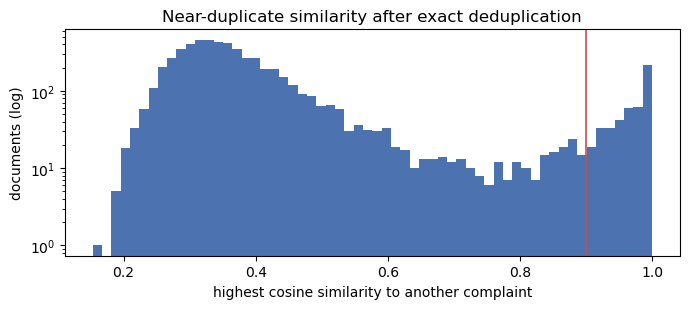

In [13]:
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(best, bins=60, color="#4c72b0")
ax.axvline(0.9, color="#c44e52", lw=1.2)
ax.set_yscale("log")
ax.set_xlabel("highest cosine similarity to another complaint")
ax.set_ylabel("documents (log)")
ax.set_title("Near-duplicate similarity after exact deduplication")
plt.tight_layout()

In [14]:
(pd.DataFrame({"Product": dd[data.LABEL_COL].values[q], "best": best})
   .groupby("Product")["best"].apply(lambda s: round(100 * (s >= 0.9).mean(), 1))
   .rename("near-dup rate % (>=0.90)").to_frame())

,near-dup rate % (>=0.90)
Product,
Checking or savings account,1.7
Credit card,2.1
Debt collection,25.9
"Money transfer, virtual currency, or money service",5.3
Student loan,5.7


1. Even after removing exact duplicates, 7.8% of documents still have a near identical twin, at least 90% similar, somewhere else in the data.
2. Most documents are genuinely unique. The median document's closest match is only 36% similar, but there is a distinct cluster of near copies sitting close to 100% similar.
3. This is heavily concentrated in Debt collection, affecting 25.9% of it, compared to 1.7 to 5.7% in other categories. More template letters.

## Near-duplicate cluster structure

If near-duplicate complaints need to stay together in the same split, train, validation, or test, the clusters of similar documents have to be checked first. Otherwise one giant cluster could distort the whole split.

In [15]:
clusters = dedup.load_clusters("../data/splits/near_dup_clusters.npy", expected_rows=len(dd))
sizes = np.bincount(clusters)
multi = sizes[sizes > 1]

pd.Series({
    "threshold": dedup.CLUSTER_THRESHOLD,
    "clusters": len(sizes),
    "singletons": int((sizes == 1).sum()),
    "multi-row clusters": len(multi),
    "rows inside them": int(multi.sum()),
    "share of corpus %": round(100 * multi.sum() / len(dd), 2),
}).to_frame("value")

,value
threshold,0.70
clusters,93805.00
singletons,91324.00
multi-row clusters,2481.00
rows inside them,10478.00
share of corpus %,10.29


In [16]:
pd.Series({
    "median": int(np.median(multi)),
    "p90": int(np.quantile(multi, 0.90)),
    "p95": int(np.quantile(multi, 0.95)),
    "p99": int(np.quantile(multi, 0.99)),
    "max": int(multi.max()),
}).to_frame("multi-row cluster size")

,multi-row cluster size
median,2
p90,4
p95,6
p99,30
max,696


In [17]:
counts = pd.Series(multi).value_counts().sort_index()
pd.concat([counts.head(6), pd.Series({">10": int((multi > 10).sum())})]).to_frame("clusters")

,clusters
2,1912
3,266
4,97
5,63
6,36
7,19
>10,59


In [18]:
# A cluster spanning several products would push the split off stratification.
per_cluster = pd.DataFrame({"c": clusters, "y": dd[data.LABEL_COL].values})
n_products = per_cluster.groupby("c")["y"].nunique()
mixed = n_products[n_products > 1].index

print("clusters spanning >1 product: %d" % len(mixed))
print("rows involved: %d (%.2f%%)" % (sizes[mixed].sum(), 100 * sizes[mixed].sum() / len(dd)))
print("largest mixed cluster: %d rows" % sizes[mixed].max())
for c in mixed[np.argsort(-sizes[mixed])][:3]:
    print(f"  cluster {c} (n={sizes[c]}):",
          {data.SHORT_LABELS[k]: v for k, v in per_cluster[per_cluster.c == c]["y"].value_counts().items()})

clusters spanning >1 product: 128
rows involved: 1177 (1.16%)
largest mixed cluster: 298 rows
  cluster 2578 (n=298): {'Money transfer': 297, 'Checking/savings': 1}
  cluster 22665 (n=152): {'Debt collection': 150, 'Credit card': 2}
  cluster 29783 (n=129): {'Debt collection': 127, 'Credit card': 2}


1. Most documents, 91,324 of them, have no near duplicate at all.
2. There are 2,481 clusters of similar documents, covering 10.3% of the data. Most are small, with 2 to 6 documents each.
3. The largest cluster has 696 rows, 0.7% of the data. That is sizeable, but not big enough to distort anything.
4. 128 clusters mix two product categories, but each one is overwhelmingly a single label. For example, one cluster has 297 Money transfer complaints against just 1 Checking or savings complaint. These are the same ambiguous dispute letters flagged earlier.
5. It is safe to keep these clusters together within a single split.

## Check the target

In [19]:
summary = data.class_summary(dd[data.LABEL_COL])
summary["raw_n"] = df[data.LABEL_COL].value_counts()
summary["lost_to_dedup_%"] = (100 * (1 - summary["n"] / summary["raw_n"])).round(1)
summary

,n,pct,raw_n,lost_to_dedup_%
Product,,,,
Checking or savings account,21524,21.14,21547,0.1
"Money transfer, virtual currency, or money service",20940,20.57,21437,2.3
Credit card,20684,20.32,20890,1.0
Student loan,19985,19.63,20111,0.6
Debt collection,18669,18.34,24007,22.2


In [20]:
print("largest / smallest :", summary["n"].max(), "/", summary["n"].min())
print("class ratio        : %.3f:1" % (summary["n"].max() / summary["n"].min()))
print("ratio before dedup : %.3f:1" % (df[data.LABEL_COL].value_counts().max()
                                       / df[data.LABEL_COL].value_counts().min()))

largest / smallest : 21524 / 18669
class ratio        : 1.153:1
ratio before dedup : 1.194:1


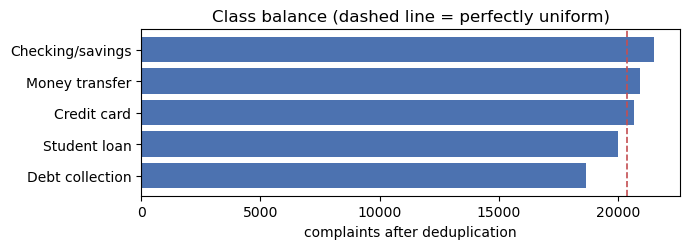

In [21]:
fig, ax = plt.subplots(figsize=(7, 2.6))
s = summary["n"].rename(index=data.SHORT_LABELS).sort_values()
ax.barh(s.index, s.values, color="#4c72b0")
ax.axvline(len(dd) / 5, color="#c44e52", lw=1.2, ls="--")
ax.set_xlabel("complaints after deduplication")
ax.set_title("Class balance (dashed line = perfectly uniform)")
plt.tight_layout()

1. After cleanup there are 101,802 rows, with classes ranging from 18,669 to 21,524 each, about a 1.15 to 1 ratio between the biggest and smallest class.
2. That is a mild imbalance, not a real problem. Every class still has roughly 19,000 training examples.
3. Class weights are not used, since at this ratio weighting would not meaningfully change the results.

## Check text length

In [22]:
words = dd[n].str.split().str.len()
chars = dd[n].str.len()
pd.DataFrame({"words": text.length_summary(words), "characters": text.length_summary(chars)})

,words,characters
min,1.0,6.0
mean,226.5,1352.9
std,214.8,1306.2
p50,178.0,1051.0
p75,288.0,1745.0
p90,436.0,2652.0
p95,570.0,3462.0
p99,1006.0,6077.0
max,5699.0,31995.0


In [23]:
by_class = (dd.assign(w=words).groupby(data.LABEL_COL)["w"]
              .agg(median="median", p75=lambda s: s.quantile(.75),
                   p90=lambda s: s.quantile(.90), mean="mean").round(0))
by_class["trunc@128_%"] = (dd.assign(t=words > 128).groupby(data.LABEL_COL)["t"]
                             .mean().mul(100).round(1))
by_class["trunc@256_%"] = (dd.assign(t=words > 256).groupby(data.LABEL_COL)["t"]
                             .mean().mul(100).round(1))
by_class.rename(index=data.SHORT_LABELS)

,median,p75,p90,mean,trunc@128_%,trunc@256_%
Product,,,,,,
Checking/savings,189.0,301.0,454.0,238.0,68.1,33.3
Credit card,207.0,319.0,470.0,252.0,72.2,37.0
Debt collection,155.0,264.0,395.0,202.0,60.3,26.3
Money transfer,167.0,269.0,402.0,214.0,62.5,27.2
Student loan,171.0,285.0,443.0,224.0,62.3,29.5


In [24]:
text.truncation_table(words, [64, 128, 192, 256, 384, 512])

,truncated_%,tokens_kept_%
max_len,,
64,86.1,26.7
128,65.2,48.1
192,46.1,63.8
256,30.8,74.6
384,13.5,86.5
512,6.6,91.9


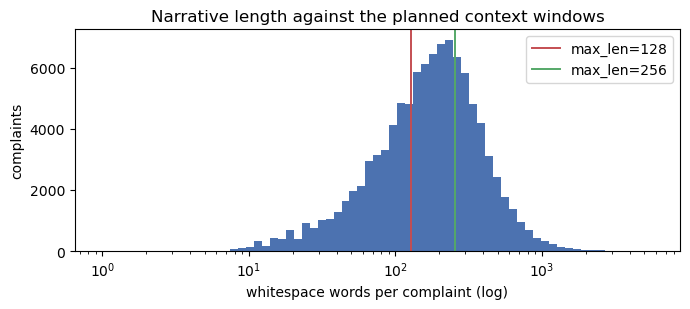

In [25]:
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(words, bins=np.logspace(0, np.log10(words.max()), 70), color="#4c72b0")
for m, c in [(128, "#c44e52"), (256, "#55a868")]:
    ax.axvline(m, color=c, lw=1.4, label=f"max_len={m}")
ax.set_xscale("log")
ax.set_xlabel("whitespace words per complaint (log)")
ax.set_ylabel("complaints")
ax.set_title("Narrative length against the planned context windows")
ax.legend()
plt.tight_layout()

1. A typical complaint is 178 words, but some run much longer. The 90th percentile is 436 words, and the longest is 5,699.
2. Cutting text at 128 words means the model only reads 48% of all the text overall. Extending to 256 words keeps 75%.
3. Longer complaints, like Credit card at a median of 207 words, get cut more than shorter ones, like Debt collection at 155 words. Truncation does not hit every category equally.
4. 203 complaints are under 10 words. They are still valid complaints and are kept as is.
5. The earlier models use a 128 word limit and the more advanced one uses 256. This matches the original plan and gives a fair before and after comparison of what extra context buys.

## Text quality

In [26]:
text.artifact_counts(dd[n])

,docs,pct
artifact,,
XXXX redaction,88331,86.77
XX/XX date,53154,52.21
year> placeholder,28036,27.54
{$...} amount,45747,44.94
bytes repr wrapper,673,0.66
url,178,0.17
email,14,0.01
html tag,8,0.01
non-ascii,0,0.00


In [27]:
# The `b'...'` rows are a byte-string repr that survived into the extract.
wrapped = dd[n].str.startswith("b'") | dd[n].str.startswith('b"')
print("rows:", int(wrapped.sum()), "| %.2f%%" % (100 * wrapped.mean()))
print(dd.loc[wrapped, data.LABEL_COL].value_counts().to_dict())
print()
print("raw     :", dd.loc[wrapped, n].iloc[1][:150])
print("unwrapped:", text.strip_bytes_wrapper(dd.loc[wrapped, n].iloc[1])[:150])

rows: 673 | 0.66%
{'Money transfer, virtual currency, or money service': 191, 'Credit card': 173, 'Checking or savings account': 140, 'Debt collection': 128, 'Student loan': 41}

raw     : b"Sofi, after XXXX  dispute XXXX XXXX appeals, XXXX  a police scam report, a identity theft affidavit, a court bank records subpoena, as scam criminal
unwrapped: Sofi, after XXXX  dispute XXXX XXXX appeals, XXXX  a police scam report, a identity theft affidavit, a court bank records subpoena, as scam criminal i


In [28]:
top_share = dd[n].str.split().apply(lambda t: Counter(t).most_common(1)[0][1] / len(t))
upper = dd[n].str.count(r"[A-Z]") / dd[n].str.len()
digits = dd[n].str.count(r"\d") / dd[n].str.len()
pd.Series({
    "one token is >30% of the doc": int((top_share > 0.30).sum()),
    "over 60% uppercase chars": int((upper > 0.60).sum()),
    "over 20% digit chars": int((digits > 0.20).sum()),
    "under 10 words": int((words < 10).sum()),
    "over 1000 words": int((words > 1000).sum()),
}).to_frame("documents")

,documents
one token is >30% of the doc,364
over 60% uppercase chars,415
over 20% digit chars,6
under 10 words,203
over 1000 words,1032


1. There is almost no junk text. URLs, emails, HTML tags, and non-English characters each make up under 0.2% of the data.
2. Some formatting quirks are actually meaningful, not noise. Half the complaints have blank lines, and 415 are mostly in all caps, which is people venting, a real tone signal.
3. 673 rows, 0.66% of the data, have a text encoding glitch, wrapped in stray byte formatting. This shows up equally across all five categories, so it is just noise, not tied to any one class.
4. The encoding glitch is fixed on those 673 rows. Everything else, capitalization, punctuation, repetition, is left untouched, since that is just how people write, and the tokenizer handles casing anyway.

## Inspect redactions

CFPB blanks out names, dates, and amounts before publishing complaints. If one category had noticeably more of these blanked out placeholders than others, a model could learn to guess the category from that pattern instead of the actual complaint. That kind of shortcut would not work on real, unredacted text.

In [29]:
x_count = text.count_matches(dd[n], r"\bX{2,}\b")
print("complaints containing XXXX: %d (%.1f%%)" % ((x_count > 0).sum(),
                                                   100 * (x_count > 0).mean()))
text.length_summary(x_count).to_frame("XXXX per complaint")

complaints containing XXXX: 88331 (86.8%)


,XXXX per complaint
min,0.0
mean,13.8
std,28.5
p50,7.0
p75,17.0
p90,32.0
p95,46.0
p99,100.0
max,4306.0


In [30]:
red = dd.assign(x=x_count, w=words, dens=100 * x_count / words)
pd.DataFrame({
    "has XXXX %": red.groupby(data.LABEL_COL)["x"].apply(lambda s: 100 * (s > 0).mean()).round(1),
    "mean count": red.groupby(data.LABEL_COL)["x"].mean().round(1),
    "median count": red.groupby(data.LABEL_COL)["x"].median(),
    "median density %": red.groupby(data.LABEL_COL)["dens"].median().round(2),
}).rename(index=data.SHORT_LABELS)

,has XXXX %,mean count,median count,median density %
Product,,,,
Checking/savings,88.9,14.1,8.0,4.29
Credit card,89.6,15.2,9.0,4.53
Debt collection,81.6,11.8,6.0,4.03
Money transfer,86.2,13.2,7.0,4.48
Student loan,86.9,14.6,7.0,4.80


In [31]:
for label in ["Credit card", "Debt collection"]:
    row = dd[dd[data.LABEL_COL] == label].iloc[3]
    print(f"--- {label} ---")
    print(row[n][:260], "\n")

--- Credit card ---
I was approached by a XXXX store associate who offered me a rewards card. I was not informed that this was a credit card or that signing up would result in a hard inquiry on my credit report. I believed I was signing up for a simple rewards/loyalty program, no 

--- Debt collection ---
I'm not sure why! We change our insurance company when our policy window came to an end. We were told by XXXX XXXX ; they would drop us if we didn't pay. We were looking for another company at the time to lower our rates, which started to get out of hand. When 



1. 86.8% of complaints contain the redaction placeholder XXXX, averaging about 14 per complaint.
2. The rate is fairly even across categories, roughly 4 to 5% of all words regardless of product. Once complaint length is accounted for, there is no real gap between categories.
3. The placeholder text is kept in. It is one of the most common words in the dataset, and removing it would erase useful signal about where a name or amount was mentioned. Both model types handle it fine as a token.

## Vocabulary

In [32]:
seqs = [text.keras_word_sequence(t) for t in dd[n]]
vocab = Counter()
for s in seqs:
    vocab.update(s)
total = sum(vocab.values())
print("vocabulary size :", len(vocab))
print("total tokens    :", total)
print("hapax           : %d (%.0f%% of types)" % (sum(1 for c in vocab.values() if c == 1),
                                                  100 * sum(1 for c in vocab.values() if c == 1) / len(vocab)))
pd.DataFrame([{"max_features": k,
               "corpus tokens covered %": round(100 * sum(c for _, c in vocab.most_common(k)) / total, 2)}
              for k in (5000, 10000, 20000, 30000, 50000)]).set_index("max_features")

vocabulary size : 57396
total tokens    : 23174386
hapax           : 27351 (48% of types)


,corpus tokens covered %
max_features,
5000,98.05
10000,99.36
20000,99.78
30000,99.88
50000,99.97


In [33]:
pd.Series(dict(vocab.most_common(15))).to_frame("count")

,count
xxxx,1057854
the,981365
i,734410
to,707881
and,653709
my,471067
a,450863
of,412261
xx,324831
that,317534


In [34]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(min_df=20, max_features=30000)
counts = cv.fit_transform(dd[n])
terms = cv.get_feature_names_out()

distinctive = {
    data.SHORT_LABELS[label]: text.top_terms_by_log_odds(
        counts, terms, (dd[data.LABEL_COL] == label).values, k=12)
    for label in data.LABELS
}
pd.DataFrame(distinctive)

,Checking/savings,Credit card,Debt collection,Money transfer,Student loan
0,webster,jetblue,1618d,abound,edfinancial
1,chexsystems,elan,credence,kraken,pslf
2,cd,citicard,waypoint,offenders,mohelas
3,marcus,comenitys,aldous,moneygram,ibr
4,etrade,lowe,procollect,abra,mohela
5,novo,barclay,sequium,unfeasible,idr
6,hsa,carecredit,tsi,infeasible,studentaid
7,axos,aadvantage,fco,remitlys,navient
8,229,kohls,ncs,eth,nelnet
9,matured,citicards,jefferson,krakens,ferpa


In [35]:
# How much vocabulary the classes actually share.
top_sets = {}
for label in data.LABELS:
    c = np.asarray(counts[(dd[data.LABEL_COL] == label).values].sum(0)).ravel()
    top_sets[data.SHORT_LABELS[label]] = set(terms[np.argsort(-c)[:2000]])
names = list(top_sets)
pd.DataFrame([[round(len(top_sets[a] & top_sets[b]) / len(top_sets[a] | top_sets[b]), 2)
               for b in names] for a in names], index=names, columns=names)

,Checking/savings,Credit card,Debt collection,Money transfer,Student loan
Checking/savings,1.00,0.74,0.58,0.79,0.60
Credit card,0.74,1.00,0.62,0.68,0.62
Debt collection,0.58,0.62,1.00,0.56,0.58
Money transfer,0.79,0.68,0.56,1.00,0.57
Student loan,0.60,0.62,0.58,0.57,1.00


1. There are 57,396 unique words in total, but almost half of them, 48%, only appear once. That is a very long tail of rare words.
2. The most common 20,000 words already cover 99.78% of all the text, so a bigger vocabulary barely helps.
3. The words that actually separate categories are brand and servicer names, for example mohela, navient, and pslf for Student loan, coinbase, zelle, and binance for Money transfer, and fdcpa for Debt collection. Categories share most of their common vocabulary and differ mainly on these specific terms.
4. The vocabulary is capped at 20,000 words. Anything rarer is mapped to a generic unknown word token instead of being dropped.

## Check leakage

There are two different things worth telling apart here. One is a model finding a shortcut unrelated to the actual complaint, which is a real problem. The other is the task just being genuinely easy because people describe their product directly, which is fine and expected.

In [36]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split

# Can the label be predicted from redaction and formatting counts alone,
# with every word thrown away?
probe = pd.DataFrame({
    "xxxx": x_count.values,
    "amounts": dd[n].str.count(r"\{\$[\d.,]+\}").values,
    "dates": dd[n].str.count(r"XX/XX/").values,
    "words": words.values,
})
probe["xxxx_density"] = probe.xxxx / probe.words
y = dd[data.LABEL_COL].values
ptr, pte, ytr, yte = train_test_split(probe, y, test_size=0.2, random_state=42, stratify=y)

for name, cols in [("redaction only", ["xxxx", "amounts", "dates", "xxxx_density"]),
                   ("length only", ["words"]),
                   ("redaction + length", list(probe.columns))]:
    m = HistGradientBoostingClassifier(max_iter=150, random_state=42).fit(ptr[cols], ytr)
    print("%-20s macro-F1 %.3f" % (name, f1_score(yte, m.predict(pte[cols]), average="macro")))
print("%-20s macro-F1 %.3f" % ("random guess", 0.200))

redaction only       macro-F1 0.274


length only          macro-F1 0.228


redaction + length   macro-F1 0.286
random guess         macro-F1 0.200


1. Using only redaction counts, with no actual complaint text, to guess the category gets 0.274 accuracy, barely better than the 0.200 you would get by guessing randomly.
2. Using the real complaint text gets 0.86. Redactions carry a tiny bit of signal, but nowhere near enough to be a shortcut.

In [37]:
# Do complaints name their own product?
cues = {
    "Checking or savings account": r"checking account|savings account|overdraft",
    "Credit card": r"credit card",
    "Debt collection": r"debt collector|collection agency|fdcpa",
    "Money transfer, virtual currency, or money service": r"zelle|venmo|paypal|cash app|crypto|wire transfer",
    "Student loan": r"student loan|navient|mohela|nelnet",
}
low = dd[n].str.lower()
rows = []
for label, pattern in cues.items():
    hit = low.str.contains(pattern, regex=True)
    inside = (dd[data.LABEL_COL] == label).values
    rows.append({"class": data.SHORT_LABELS[label],
                 "cue in class %": round(100 * hit[inside].mean(), 1),
                 "cue elsewhere %": round(100 * hit[~inside].mean(), 1)})
pd.DataFrame(rows).set_index("class")

,cue in class %,cue elsewhere %
class,,
Checking/savings,27.6,3.2
Credit card,47.5,3.3
Debt collection,40.2,1.0
Money transfer,49.2,3.1
Student loan,70.9,0.2


People often name their product directly in the complaint, 28 to 71% of the time depending on category, and rarely mention other products, under 3.3%. That is realistic. It is what a real classifier would rely on too, not a sign of a flawed dataset.

## TF-IDF reference

This is just a quick reference check, not one of the actual models being compared. It uses a temporary data split for measurement only. The real train and test split is built in the next stage.

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

idx_tr, idx_te = train_test_split(np.arange(len(dd)), test_size=0.10,
                                  random_state=42, stratify=y)
vec = TfidfVectorizer(min_df=3, max_features=60000, sublinear_tf=True,
                      strip_accents="unicode")
Xtr = vec.fit_transform(dd[n].iloc[idx_tr])
Xte = vec.transform(dd[n].iloc[idx_te])
clf = LogisticRegression(max_iter=400, C=4.0).fit(Xtr, y[idx_tr])
pred = clf.predict(Xte)
print(classification_report(y[idx_te], pred, digits=3))

                                                    precision    recall  f1-score   support

                       Checking or savings account      0.756     0.790     0.772      2153
                                       Credit card      0.861     0.845     0.853      2068
                                   Debt collection      0.913     0.924     0.918      1867
Money transfer, virtual currency, or money service      0.820     0.799     0.809      2094
                                      Student loan      0.972     0.958     0.965      1999

                                          accuracy                          0.860     10181
                                         macro avg      0.864     0.863     0.863     10181
                                      weighted avg      0.861     0.860     0.861     10181



In [39]:
pd.DataFrame(confusion_matrix(y[idx_te], pred, labels=data.LABELS),
             index=[data.SHORT_LABELS[l] for l in data.LABELS],
             columns=[data.SHORT_LABELS[l] for l in data.LABELS])

,Checking/savings,Credit card,Debt collection,Money transfer,Student loan
Checking/savings,1700,139,18,291,5
Credit card,157,1747,91,62,11
Debt collection,21,80,1725,11,30
Money transfer,360,46,6,1673,9
Student loan,12,18,50,4,1915


1. A basic bag of words model already gets 0.863 Macro F1, pretty strong for something this simple.
2. The easiest category is Student loan at 0.965 F1. The hardest is Checking or savings at 0.772 F1.
3. The main confusion is between Checking or savings and Money transfer, which makes sense since both are account level payment issues.
4. This is just a reference point, not a target the real models need to beat.

In [40]:
# How much of that 0.864 is near-duplicate contamination?
best_te = text.max_similarity(A[idx_te], A[idx_tr], exclude=None)
rows = []
for thr in (0.95, 0.90, 0.80):
    hit = best_te >= thr
    rows.append({
        "threshold": thr,
        "test docs with a train near-dup": int(hit.sum()),
        "%": round(100 * hit.mean(), 2),
        "macro-F1 on those": round(f1_score(y[idx_te][hit], pred[hit], average="macro"), 3),
        "macro-F1 on the rest": round(f1_score(y[idx_te][~hit], pred[~hit], average="macro"), 3),
    })
pd.DataFrame(rows).set_index("threshold")

,test docs with a train near-dup,%,macro-F1 on those,macro-F1 on the rest
threshold,,,,
0.95,541,5.31,0.924,0.859
0.90,724,7.11,0.922,0.858
0.80,890,8.74,0.889,0.858


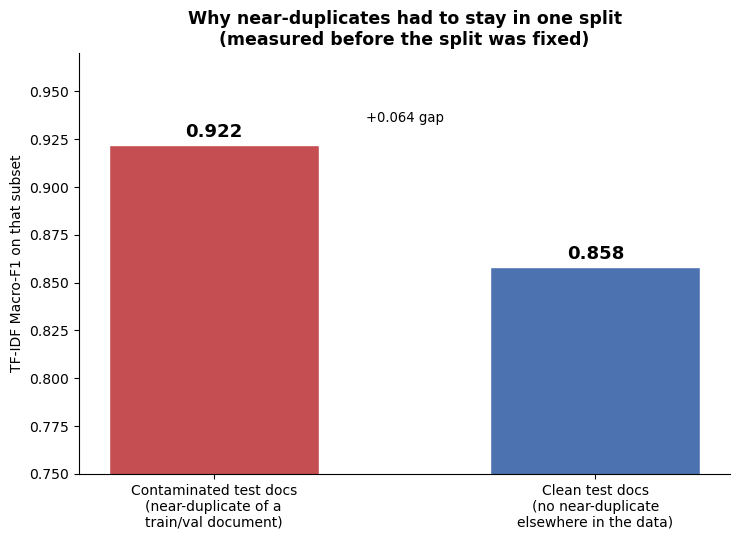

In [41]:
row90 = next(r for r in rows if r["threshold"] == 0.90)
fig, ax = plt.subplots(figsize=(7.5, 5.5))
labels = ["Contaminated test docs\n(near-duplicate of a\ntrain/val document)",
          "Clean test docs\n(no near-duplicate\nelsewhere in the data)"]
scores = [row90["macro-F1 on those"], row90["macro-F1 on the rest"]]
bars = ax.bar(labels, scores, color=["#C44E52", "#4C72B0"], width=0.55, edgecolor="white")
for bar, s in zip(bars, scores):
    ax.annotate(f"{s:.3f}", (bar.get_x() + bar.get_width() / 2, s), textcoords="offset points",
                xytext=(0, 6), ha="center", fontsize=13, fontweight="bold")
gap = scores[0] - scores[1]
ax.text(0.5, max(scores) + 0.012, f"+{gap:.3f} gap", ha="center", fontsize=9.5, transform=ax.transData)
ax.set_ylabel("TF-IDF Macro-F1 on that subset")
ax.set_ylim(0.75, 0.97)
ax.set_title("Why near-duplicates had to stay in one split\n(measured before the split was fixed)",
             fontsize=12.5, fontweight="bold")
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout()
fig.savefig("../assets/near_duplicate_leakage.png", dpi=150, bbox_inches="tight")
plt.show()


In [42]:
# Which classes the contaminated test documents belong to.
(pd.Series(y[idx_te][best_te >= 0.90]).value_counts()
   .rename(index=data.SHORT_LABELS).rename("contaminated test docs").to_frame())

,contaminated test docs
Debt collection,412
Student loan,118
Money transfer,116
Credit card,53
Checking/savings,25


1. 7.1% of the test set has a near identical twin sitting in the training set, meaning the model has basically already seen it.
2. On those documents the model scores 0.922, compared to 0.858 on everything else. That gap inflates the overall score by roughly 0.45 points.
3. 57% of this overlap is Debt collection complaints, so that category's score is the most affected.
4. The train, validation, and test split needs to keep near-duplicate groups together in one split instead of scattering them across all three. Exact duplicate removal alone is not enough. This does not change the dataset size, the split ratios, or which models get tested, just how the split is built.

## Token lengths

Word counts so far were just whitespace split words, which is not actually what either model sees. The LSTM tokenizer splits differently, and the transformer tokenizer breaks unfamiliar words, like jargon and redaction markers, into smaller sub-word pieces. Real sequence lengths need to be measured separately for each tokenizer.

In [43]:
from transformers import AutoTokenizer

keras_len = np.array([len(s) for s in seqs])
wp_tok = AutoTokenizer.from_pretrained("distilbert-base-uncased")
wp_len = text.wordpiece_lengths(dd[n], wp_tok)

pd.DataFrame({
    "whitespace": text.length_summary(words),
    "keras": text.length_summary(keras_len),
    "distilbert wordpiece": text.length_summary(wp_len),
})

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1015 > 512). Running this sequence through the model will result in indexing errors


,whitespace,keras,distilbert wordpiece
min,1.0,1.0,5.0
mean,226.5,227.6,292.0
std,214.8,214.7,286.1
p50,178.0,180.0,228.0
p75,288.0,290.0,369.0
p90,436.0,438.0,563.0
p95,570.0,569.0,736.0
p99,1006.0,1008.0,1317.0
max,5699.0,5830.0,9071.0


In [44]:
print(wp_tok.tokenize("XXXX XX/XX/2024 {$1500.00} ACH chargeback overdraft Navient forbearance"))
print("wordpiece / keras length ratio: median %.2f, p90 %.2f"
      % (np.median(wp_len / keras_len), np.quantile(wp_len / keras_len, 0.9)))

['xx', '##xx', 'xx', '/', 'xx', '/', '202', '##4', '{', '$', '1500', '.', '00', '}', 'ac', '##h', 'charge', '##back', 'over', '##dra', '##ft', 'na', '##vie', '##nt', 'for', '##be', '##aran', '##ce']
wordpiece / keras length ratio: median 1.26, p90 1.42


In [45]:
pd.concat({"keras": text.truncation_table(keras_len, [128, 256, 512]),
           "distilbert": text.truncation_table(wp_len, [128, 256, 512])}, axis=0)

truncated_%  tokens_kept_%
           max_len                            
keras      128             65.6           48.0
           256             31.0           74.6
           512              6.6           91.9
distilbert 128             74.4           39.2
           256             43.9           64.9
           512             12.5           86.8

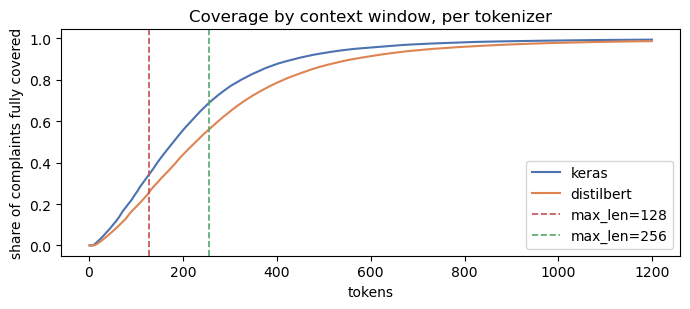

In [46]:
fig, ax = plt.subplots(figsize=(7, 3.2))
grid = np.arange(1, 1200)
for name, L, colour in [("keras", keras_len, "#4c72b0"), ("distilbert", wp_len, "#dd8452")]:
    ax.plot(grid, np.searchsorted(np.sort(L), grid, side="right") / len(L),
            label=name, color=colour)
for m, c in [(128, "#c44e52"), (256, "#55a868")]:
    ax.axvline(m, color=c, lw=1.2, ls="--", label=f"max_len={m}")
ax.set_xlabel("tokens")
ax.set_ylabel("share of complaints fully covered")
ax.set_title("Coverage by context window, per tokenizer")
ax.legend()
plt.tight_layout()

1. The transformer tokenizer breaks words into more pieces than the LSTM tokenizer does, about 26% more tokens per complaint on average. The median length is 178 for LSTM and 228 for the transformer.
2. This means that at the same length cutoff, the transformer actually sees less of each complaint. At a 256 token limit, the LSTM keeps about 69% of a typical complaint while the transformer keeps only 56%.
3. This happens because financial terms and redaction placeholders get chopped into sub-pieces. For example, navient becomes na, vie, and nt.
4. The same length limit is kept across models for a fair comparison, but the transformer is technically working with less context per complaint. If it still wins despite that handicap, the result is more convincing. If it loses narrowly, this is the first thing to check.

## GloVe coverage

One experiment swaps in pre-trained GloVe word vectors instead of starting from random ones. That is only a fair test if GloVe actually covers this dataset's vocabulary, checked below.

In [47]:
glove = embeddings.load_glove_vocab("../data/embeddings/glove.6B.100d.txt")
print("glove vocabulary:", len(glove))
embeddings.coverage(vocab, glove, [1000, 5000, 10000, 20000, 30000, None])

glove vocabulary: 400001


,types_in_glove_%,tokens_in_glove_%,corpus_covered_%
vocab_size,,,
1000,98.6,99.60,86.31
5000,97.2,99.32,97.39
10000,94.1,99.23,98.60
20000,86.5,99.16,98.94
30000,76.3,99.11,99.00
57396,53.0,99.03,99.03


In [48]:
pd.DataFrame(embeddings.missing_terms(vocab, glove, 20000, k=24),
             columns=["term", "corpus count"]).set_index("term")

,corpus count
term,
mohela,20791
fdcpa,8272
navient,6349
didn't,5575
i'm,5074
don't,4963
pslf,4338
i've,4180
coinbase,4102


In [49]:
# Coverage on the terms that actually separate the classes.
pd.DataFrame([
    {"class": short,
     "distinctive terms in glove": f"{sum(1 for t in terms_ if t in glove)}/{len(terms_)}"}
    for short, terms_ in {
        data.SHORT_LABELS[label]: text.top_terms_by_log_odds(
            counts, terms, (dd[data.LABEL_COL] == label).values, k=30)
        for label in data.LABELS}.items()
]).set_index("class")

,distinctive terms in glove
class,
Checking/savings,26/30
Credit card,21/30
Debt collection,23/30
Money transfer,15/30
Student loan,18/30


In [50]:
# Contractions miss because the Keras filter keeps the apostrophe and GloVe's
# tokenizer splits on it. Worth deviating from the default filters?
split_apostrophes = Counter()
for word, c in vocab.items():
    for part in (word.split("'") if "'" in word else [word]):
        if part:
            split_apostrophes[part] += c
pd.concat({"keras defaults": embeddings.coverage(vocab, glove, [20000]),
           "apostrophe stripped": embeddings.coverage(split_apostrophes, glove, [20000])})

,,types_in_glove_%,tokens_in_glove_%,corpus_covered_%
,vocab_size,,,
keras defaults,20000,86.5,99.16,98.94
apostrophe stripped,20000,87.4,99.35,99.14


1. GloVe covers 99.16% of all word occurrences in the dataset. That looks great, but the number is misleading.
2. The words GloVe is missing are not random junk. They are exactly the words that matter most for telling categories apart, brand and servicer names like mohela, navient, coinbase, and fdcpa.
3. For Money transfer and Student loan, GloVe only has vectors for about half of the most distinctive words in that category, 15 out of 30 and 18 out of 30. For Checking or savings it is much better, 26 out of 30.
4. The experiment still runs as planned, since coverage is high enough overall to mean something. But the improvement should be smaller than the 99% number suggests, since the words that actually distinguish categories are the ones missing. Words without a GloVe vector still start from a trainable random vector, so they can still learn from the training data.

## Audit findings

| Finding | Evidence | What was done |
|---|---|---|
| Schema and labels as specified | 107,992 rows, 16 columns, 5 products, unique complaint IDs, 0 nulls or blanks | Used the complaint text and product columns only, no relabeling |
| Heavy exact duplication | 7,038 rows over 848 texts, largest groups 832, 293, 238, 85% in Debt collection | Removed duplicate text before splitting, down to 101,802 rows |
| Ambiguous labels | 7 texts, 49 rows, filed under more than one product | Kept as is. Label noise floor of 0.05%, explains part of the Debt collection and Credit card confusion |
| Near-duplicate leakage | 7.8% of documents have a 90%+ similar twin, 25.9% within Debt collection | Exact dedup was not enough, the split must keep near-duplicate clusters intact |
| Leakage is real | TF-IDF scores 0.922 Macro F1 on contaminated test documents versus 0.858 on clean ones, about 0.45 points of the overall score | This justified changing how the split is built |
| Mild class imbalance | 1.153 to 1 after dedup, smallest class 18.3% | Class weights were not used |
| Long right tail | median 178 words, 90th percentile 436, max 5,699 | Kept the earlier models at 128 words, the later one at 256 |
| WordPiece inflates length | median 1.26x longer, 43.9% truncated at 256 for the transformer versus 31.0% for the LSTM | Kept the same limits, noted the unequal context as a caveat |
| Redaction is not a shortcut | XXXX appears in 86.8% of documents, redaction-only guessing gets 0.274 Macro F1 versus 0.200 by chance | Kept XXXX in the text, logged as a weak confound |
| Encoding damage | 673 rows, 0.66%, wrapped in stray byte formatting, present in all five classes | Fixed at preprocessing |
| Task is strongly lexical | TF-IDF plus logistic regression reaches 0.863 Macro F1, product names appear in 28 to 71% of their own class versus 0.2 to 3.3% elsewhere | This is realistic signal, not leakage |
| Vocabulary is long tailed | 57,396 words, 48% appear once, top 20,000 cover 99.78% of tokens | Capped vocabulary at 20,000 words with an unknown word token |
| GloVe misses the signal words | 99.16% token coverage, but only 15 to 26 out of each class's top 30 distinctive terms are covered | Still ran the GloVe experiment, expecting a smaller gain than raw coverage suggests |

Ready to move on? Yes, with one change.

The data, labels, and structure all check out, and nothing was dropped without a clear reason. Two things that could have quietly broken the experiment, redaction patterns being a shortcut, and the task being too easy for a bad reason, were checked directly, and both turned out fine.

The one real change is the split. The train, validation, and test data need to keep near-duplicate complaints together, since scattering them across splits was inflating scores. Everything else, the models being compared, the number of training runs, the metric, stays as planned.

## Freeze the data config

In [51]:
import json
from pathlib import Path

data_config = {
    "dataset": {
        "path": "data/combined_complaints.parquet",
        "text_column": data.TEXT_COL,
        "label_column": data.LABEL_COL,
        "labels": data.LABELS,
        "rows_raw": int(len(df)),
        "rows_after_dedup": int(len(dd)),
    },
    "cleaning": {
        "deduplicate_on": "narrative, keep first",
        "rows_removed": int(len(df) - len(dd)),
        "strip_bytes_repr_wrapper": True,
        "keep_xxxx_redactions": True,
        "lowercase": "left to each tokenizer",
    },
    "split": {
        "train_val_test": [0.8, 0.1, 0.1],
        "stratify_on": data.LABEL_COL,
        "group_by": f"near-duplicate cluster, tfidf cosine >= {dedup.CLUSTER_THRESHOLD}",
        "seed": 42,
    },
    "keras_tokenizer": {
        "max_features": 20000,
        "oov_token": "<OOV>",
        "filters": text.KERAS_FILTERS,
        "lower": True,
        "max_len": {"M0": 128, "M1": 128, "M2": 128, "M3": 128, "M4": 256},
    },
    "distilbert": {
        "checkpoint": "distilbert-base-uncased",
        "max_len": 256,
    },
    "glove": {
        "path": "data/embeddings/glove.6B.100d.txt",
        "dim": embeddings.GLOVE_DIM,
        "trainable": True,
    },
    "class_weights": {"enabled": False, "reason": "class ratio 1.153:1 after dedup"},
    "audit": {
        "class_ratio": round(float(summary["n"].max() / summary["n"].min()), 3),
        "words_median": int(words.median()),
        "words_p90": int(words.quantile(0.90)),
        "keras_truncated_at_128_%": float(text.truncation_table(keras_len, [128]).loc[128, "truncated_%"]),
        "keras_truncated_at_256_%": float(text.truncation_table(keras_len, [256]).loc[256, "truncated_%"]),
        "wordpiece_truncated_at_128_%": float(text.truncation_table(wp_len, [128]).loc[128, "truncated_%"]),
        "wordpiece_truncated_at_256_%": float(text.truncation_table(wp_len, [256]).loc[256, "truncated_%"]),
        "vocabulary_types": len(vocab),
        "glove_token_coverage_%": float(embeddings.coverage(vocab, glove, [20000]).loc[20000, "tokens_in_glove_%"]),
        "glove_oov_token_%": round(100 - float(embeddings.coverage(vocab, glove, [20000]).loc[20000, "tokens_in_glove_%"]), 2),
        "xxxx_present_%": round(float(100 * (x_count > 0).mean()), 1),
        "near_duplicate_rate_at_0.90_%": round(float(100 * (best >= 0.90).mean()), 1),
        "near_duplicate_rate_at_grouping_threshold_%": round(float(100 * (best >= dedup.CLUSTER_THRESHOLD).mean()), 1),
        "tfidf_reference_macro_f1": round(float(f1_score(y[idx_te], pred, average="macro")), 3),
    },
}

Path("../configs").mkdir(exist_ok=True)
Path("../configs/data_config.json").write_text(json.dumps(data_config, indent=2), encoding="utf-8")
print(json.dumps(data_config, indent=2))

{
  "dataset": {
    "path": "data/combined_complaints.parquet",
    "text_column": "Consumer complaint narrative",
    "label_column": "Product",
    "labels": [
      "Checking or savings account",
      "Credit card",
      "Debt collection",
      "Money transfer, virtual currency, or money service",
      "Student loan"
    ],
    "rows_raw": 107992,
    "rows_after_dedup": 101802
  },
  "cleaning": {
    "deduplicate_on": "narrative, keep first",
    "rows_removed": 6190,
    "strip_bytes_repr_wrapper": true,
    "keep_xxxx_redactions": true,
    "lowercase": "left to each tokenizer"
  },
  "split": {
    "train_val_test": [
      0.8,
      0.1,
      0.1
    ],
    "stratify_on": "Product",
    "group_by": "near-duplicate cluster, tfidf cosine >= 0.7",
    "seed": 42
  },
  "keras_tokenizer": {
    "max_features": 20000,
    "oov_token": "<OOV>",
    "filters": "!\"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n",
    "lower": true,
    "max_len": {
      "M0": 128,
      "M1": 128,
      "

Every setting saved here, vocabulary size, max text length, skipping class weights, keeping near-duplicates grouped, GloVe setup, comes from an actual measurement above, not a default guess. The next stage builds the data split using these settings.

## Report charts

The three charts below reuse the exact variables computed above (`dd`, `words`, `keras_len`, `wp_len`) purely to export them as PNGs for the project README - no new analysis, no new numbers.

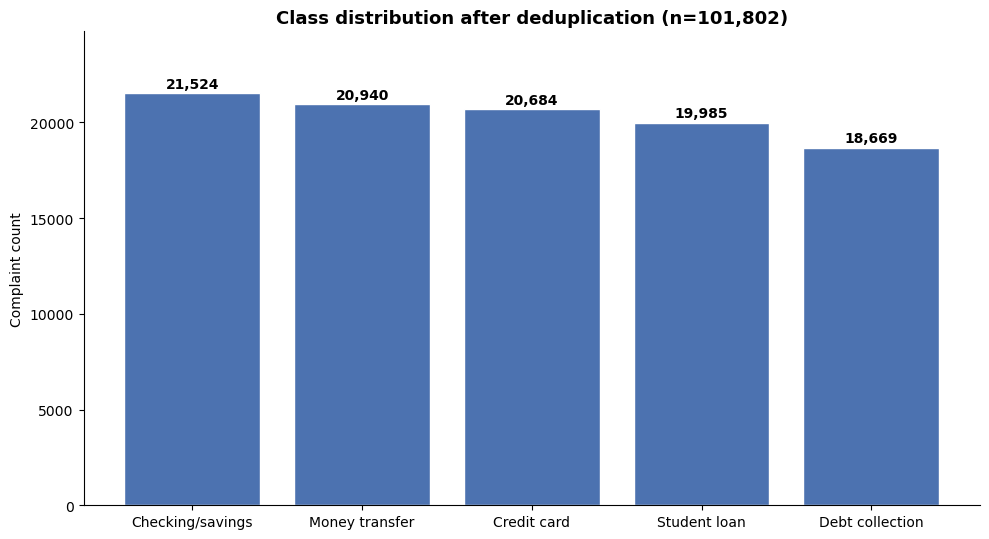

In [52]:
counts = dd[data.LABEL_COL].value_counts()
fig, ax = plt.subplots(figsize=(10, 5.5))
bars = ax.bar([data.SHORT_LABELS[l] for l in counts.index], counts.values, color="#4C72B0", edgecolor="white")
for bar, c in zip(bars, counts.values):
    ax.annotate(f"{c:,}", (bar.get_x() + bar.get_width() / 2, c), textcoords="offset points",
                xytext=(0, 4), ha="center", fontsize=10, fontweight="bold")
ax.set_ylabel("Complaint count")
ax.set_title(f"Class distribution after deduplication (n={len(dd):,})", fontsize=13, fontweight="bold")
ax.set_ylim(0, counts.max() * 1.15)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout()
fig.savefig("../assets/class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


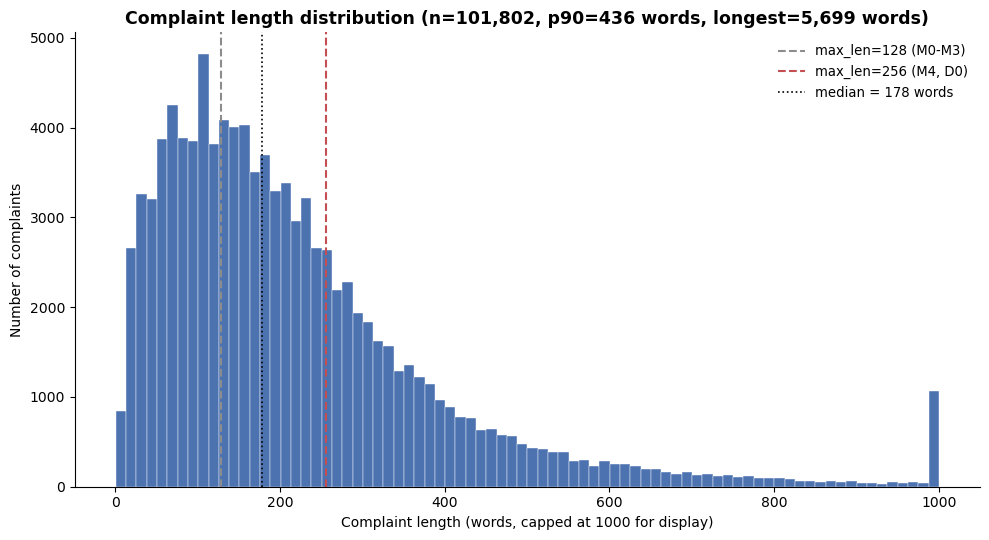

In [53]:
median_w, p90_w = float(words.median()), float(words.quantile(0.9))
fig, ax = plt.subplots(figsize=(10, 5.5))
capped = np.minimum(words.values, 1000)
ax.hist(capped, bins=80, color="#4C72B0", edgecolor="white", linewidth=0.3)
ax.axvline(128, color="#8C8C8C", linestyle="--", linewidth=1.5, label="max_len=128 (M0-M3)")
ax.axvline(256, color="#C44E52", linestyle="--", linewidth=1.5, label="max_len=256 (M4, D0)")
ax.axvline(median_w, color="black", linestyle=":", linewidth=1.2, label=f"median = {median_w:.0f} words")
ax.set_xlabel("Complaint length (words, capped at 1000 for display)")
ax.set_ylabel("Number of complaints")
ax.set_title(f"Complaint length distribution (n={len(words):,}, p90={p90_w:.0f} words, longest={int(words.max()):,} words)",
             fontsize=12.5, fontweight="bold")
ax.legend(frameon=False, fontsize=9.5)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout()
fig.savefig("../assets/length_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


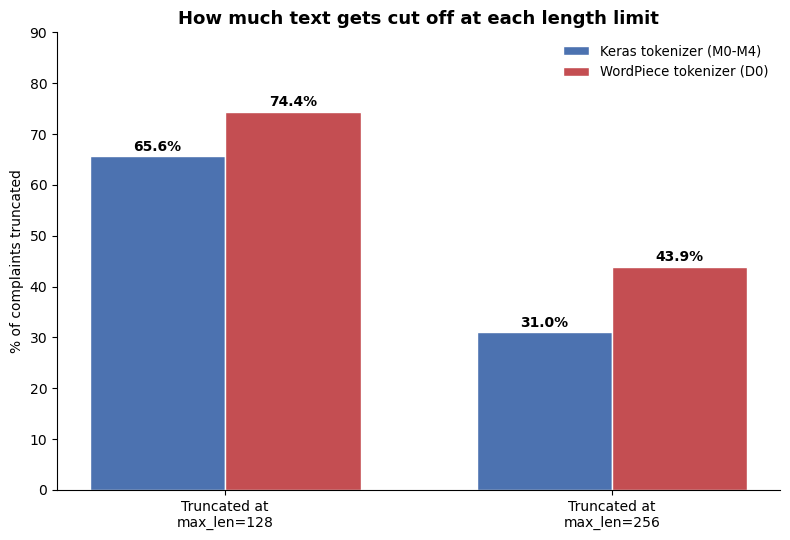

In [54]:
keras_tab = text.truncation_table(keras_len, [128, 256])
wp_tab = text.truncation_table(wp_len, [128, 256])
fig, ax = plt.subplots(figsize=(8, 5.5))
x = np.arange(2); width = 0.35
b1 = ax.bar(x - width / 2, keras_tab["truncated_%"].values, width, label="Keras tokenizer (M0-M4)", color="#4C72B0", edgecolor="white")
b2 = ax.bar(x + width / 2, wp_tab["truncated_%"].values, width, label="WordPiece tokenizer (D0)", color="#C44E52", edgecolor="white")
for bars in (b1, b2):
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f"{h:.1f}%", (bar.get_x() + bar.get_width() / 2, h), textcoords="offset points",
                    xytext=(0, 4), ha="center", fontsize=10, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(["Truncated at\nmax_len=128", "Truncated at\nmax_len=256"])
ax.set_ylabel("% of complaints truncated")
ax.set_title("How much text gets cut off at each length limit", fontsize=13, fontweight="bold")
ax.set_ylim(0, 90)
ax.legend(frameon=False, fontsize=9.5)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout()
fig.savefig("../assets/truncation_rates.png", dpi=150, bbox_inches="tight")
plt.show()
